# K-nearest neighbours EDA

## Importación de librerías y paquetes y definición de constantes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Imputador
from sklearn.impute import KNNImputer
# Modelado
from sklearn.linear_model import LogisticRegression
# Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# from tqdm import tqdm
import warnings


In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Recopilación de datos

In [3]:
df = pd.read_csv("../data/raw/winequality-red.csv", sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Análisis descriptivo 

In [4]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [5]:
df.shape

(1599, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
df.nunique()

fixed acidity            96
volatile acidity        143
citric acid              80
residual sugar           91
chlorides               153
free sulfur dioxide      60
total sulfur dioxide    144
density                 436
pH                       89
sulphates                96
alcohol                  65
quality                   6
dtype: int64

## Limpieza de datos

### Eliminar duplicados:

In [8]:
df.duplicated().sum()

np.int64(240)

### No hay duplicados pero nos aseguramos de borrarlos

In [9]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(1359, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


In [10]:
df.duplicated().sum()

np.int64(0)

### Valores nulos o faltantes:

In [11]:
df.isnull().sum().sort_values(ascending=False) / len(df)

fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

#### No hay valores nulos

In [12]:
df['quality']

0       5
1       5
2       5
3       6
5       5
       ..
1593    6
1594    5
1595    6
1597    5
1598    6
Name: quality, Length: 1359, dtype: int64

### Limpieza de datos: Eliminar información irrelevante

In [13]:
corr_quality = df.corr()['quality'].drop('quality').abs().sort_values(ascending=False)
corr_quality

alcohol                 0.480343
volatile acidity        0.395214
sulphates               0.248835
citric acid             0.228057
density                 0.184252
total sulfur dioxide    0.177855
chlorides               0.130988
fixed acidity           0.119024
pH                      0.055245
free sulfur dioxide     0.050463
residual sugar          0.013640
Name: quality, dtype: float64

#### No eliminamos ninguna variable porque pueden tener cierta influencia en la variable objetivo

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


## Análisis de variables:

### Variables univariante: variables númericas

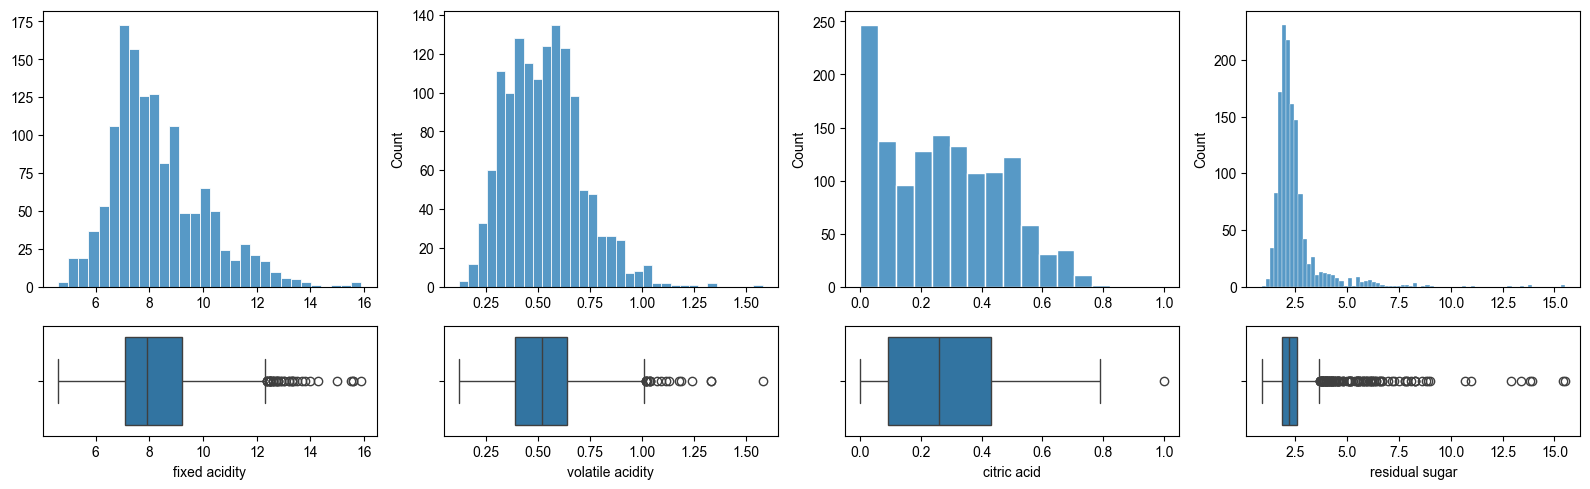

In [15]:
fig, axis = plt.subplots(2, 4, figsize=(16, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="fixed acidity").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="fixed acidity")
sns.histplot(ax=axis[0, 1], data=df, x="volatile acidity").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="volatile acidity")
sns.histplot(ax=axis[0, 2], data=df, x="citric acid").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="citric acid")
sns.histplot(ax=axis[0, 3], data=df, x="residual sugar").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="residual sugar")
plt.tight_layout()
plt.show()

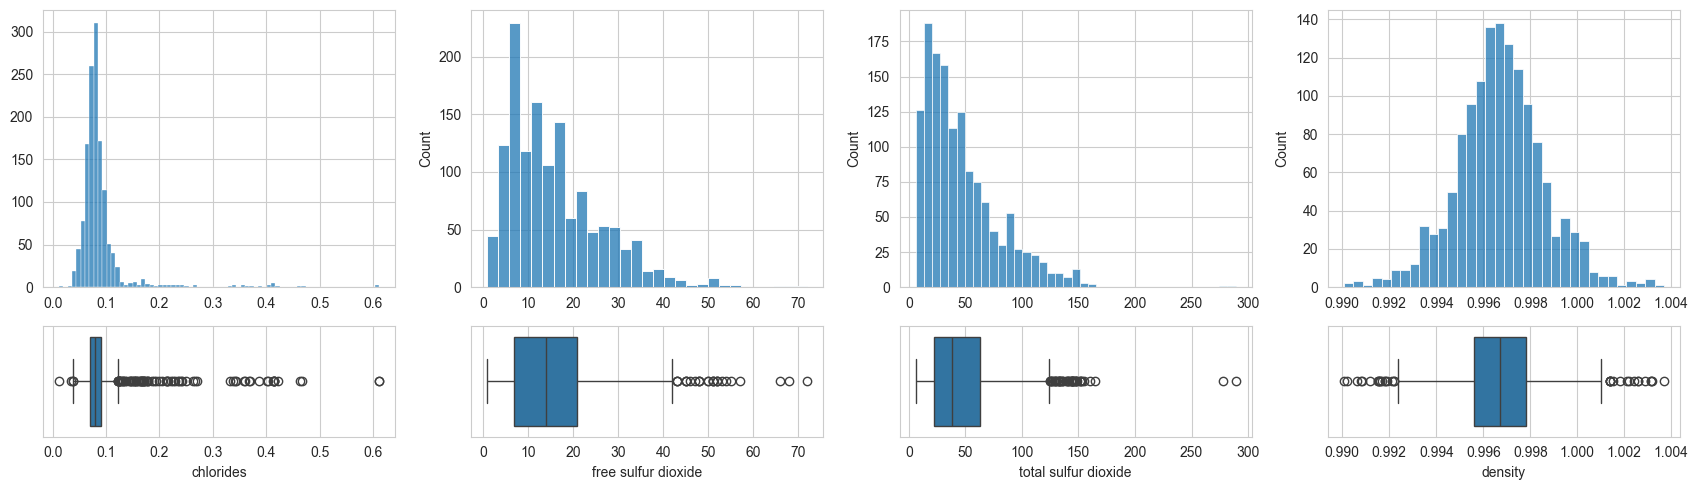

In [16]:
fig, axis = plt.subplots(2, 4, figsize=(17, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="chlorides").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="chlorides")
sns.histplot(ax=axis[0, 1], data=df, x="free sulfur dioxide").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="free sulfur dioxide")
sns.histplot(ax=axis[0, 2], data=df, x="total sulfur dioxide").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="total sulfur dioxide")
sns.histplot(ax=axis[0, 3], data=df, x="density").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="density")

plt.tight_layout()
plt.show()

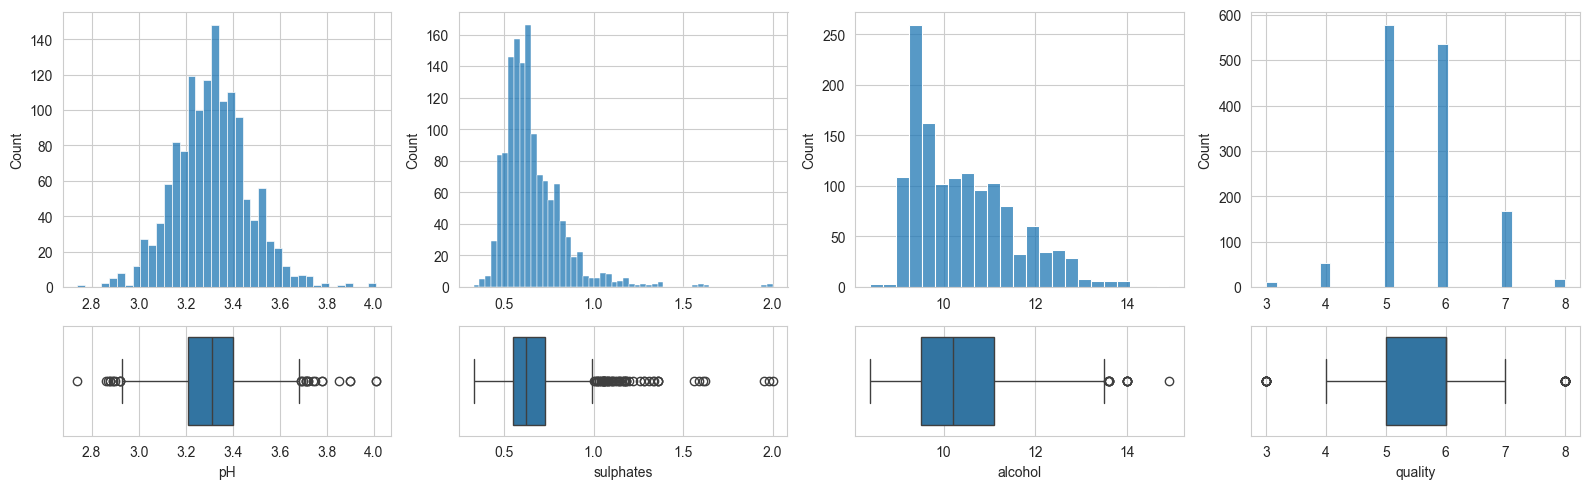

In [17]:
fig, axis = plt.subplots(2, 4, figsize=(16, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="pH").set(xlabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="pH")
sns.histplot(ax=axis[0, 1], data=df, x="sulphates").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="sulphates")
sns.histplot(ax=axis[0, 2], data=df, x="alcohol").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="alcohol")
sns.histplot(ax=axis[0, 3], data=df, x="quality").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="quality")
plt.tight_layout()
plt.show()

> #### Observaciones:
>
> - La combinación de los dos gráficos nos permite conocer las distribuciones y sus características estadísticas.
> - De la visualización resultante podemos tener claro las variables que cuentan con valores atípicos.
> - La variables siguen una distribución normalizada un poco sesgada hacia la izquierda

### Análisis de Variables Multivariante: procedemos a buscar todas las posibles relaciones que existen entre las variables

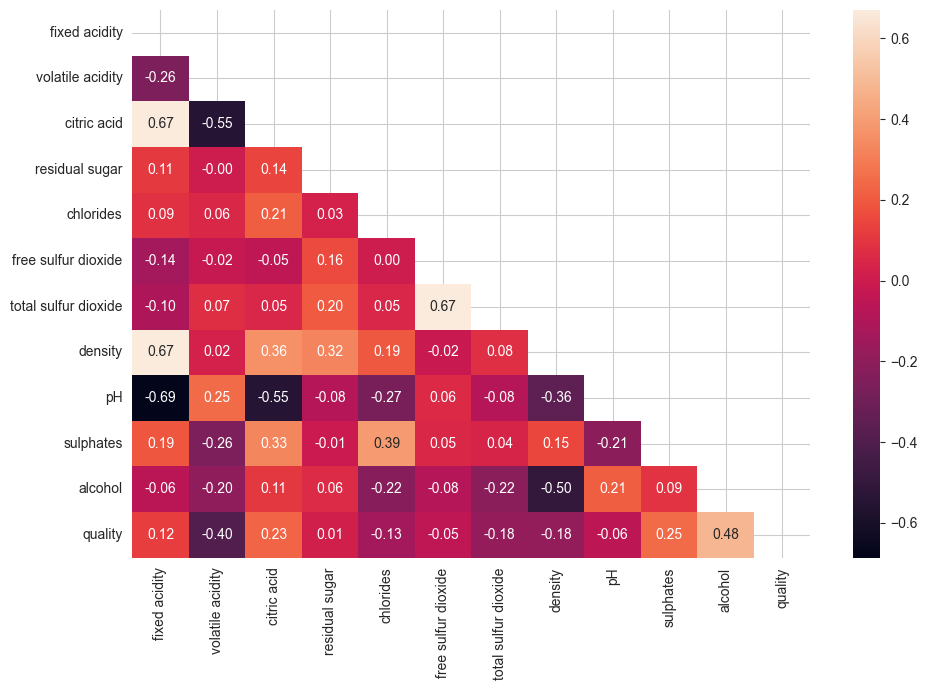

In [18]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

### Observaciones:

Parece que todas las variables estan relacionadas de forma directa e indirecta, 'quality' se relaciona con 'volatile acidity' que a su vez se relaciona con 'citric acid', 'citric acid' se relaciona con 'fixed acidity' que se relaciona fuertemente con 'density' y 'ph'

### Correlaciones con la variable objetivo:

### Análisis de variables multivariante: númerico-númerico

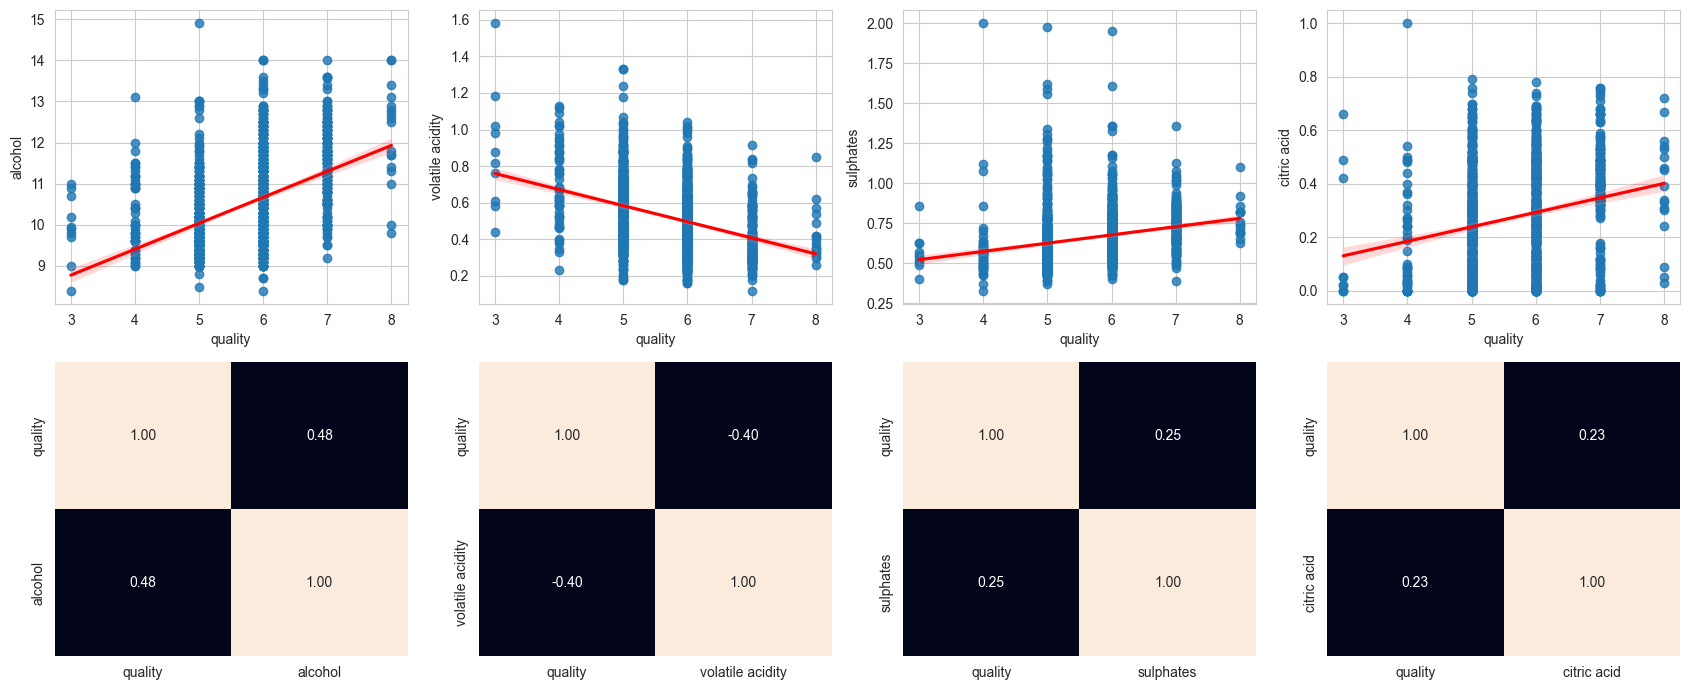

In [19]:
corr_quality_alcohol = df[["quality", "alcohol"]].corr()
corr_quality_volatile = df[["quality", "volatile acidity"]].corr()
corr_quality_sulphates = df[["quality", "sulphates"]].corr()
corr_quality_citric = df[["quality", "citric acid"]].corr()
fig, axis = plt.subplots(2, 4, figsize=(17, 7))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="quality", y="alcohol", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_quality_alcohol, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="quality", y="volatile acidity", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_quality_volatile, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="quality", y="sulphates", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_quality_sulphates, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,3], data=df, x="quality", y="citric acid", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,3], data=corr_quality_citric, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

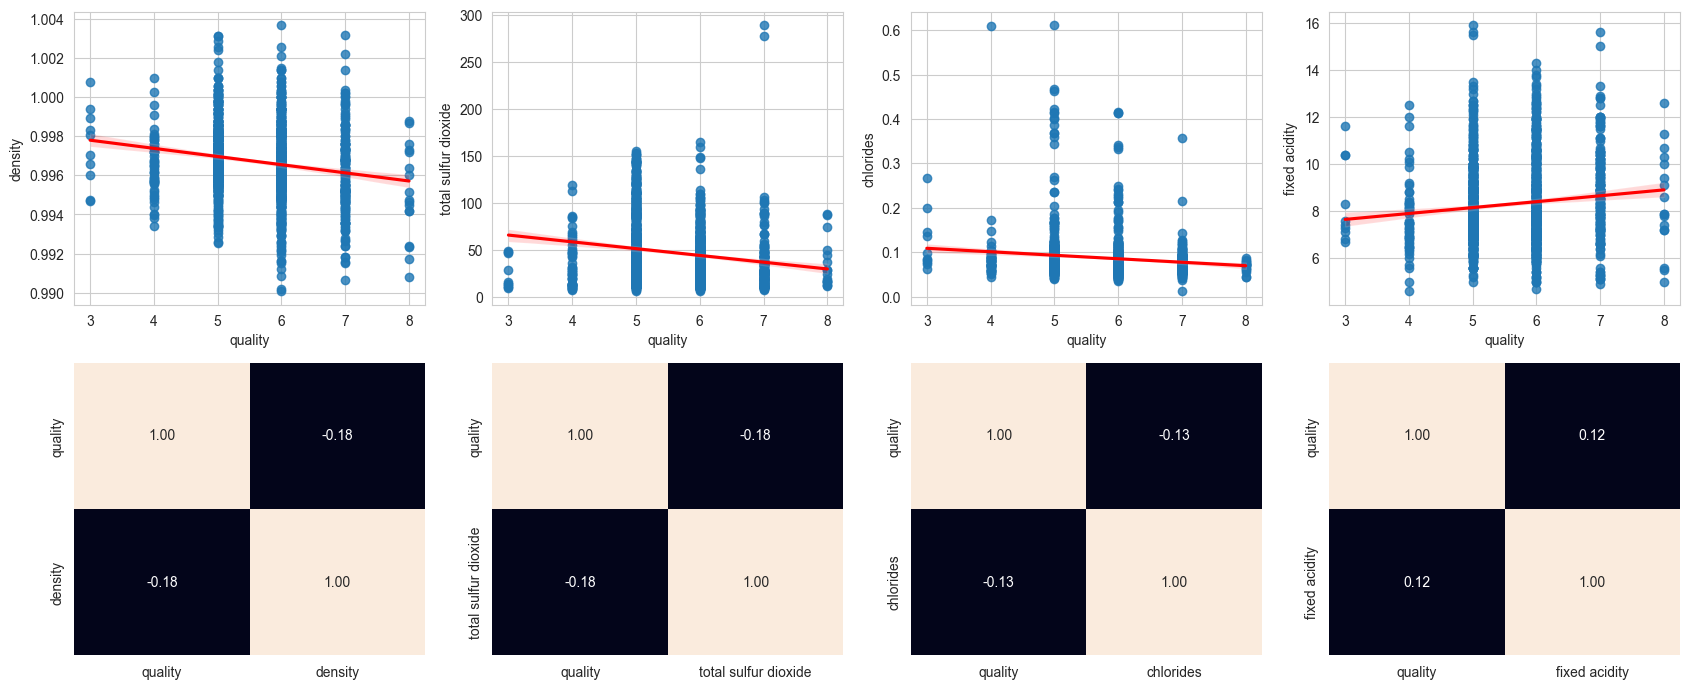

In [20]:
corr_quality_density = df[["quality", "density"]].corr()
corr_quality_sulfur = df[["quality", "total sulfur dioxide"]].corr()
corr_quality_chlorides = df[["quality", "chlorides"]].corr()
corr_quality_fixed = df[["quality", "fixed acidity"]].corr()
fig, axis = plt.subplots(2, 4, figsize=(17, 7))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="quality", y="density", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_quality_density, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="quality", y="total sulfur dioxide", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_quality_sulfur, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="quality", y="chlorides", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_quality_chlorides, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,3], data=df, x="quality", y="fixed acidity", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,3], data=corr_quality_fixed, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

Parece que todas las variables estan relacionadas de forma directa e indirecta, 'quality' se relaciona con 'volatile acidity' que a su vez se relaciona con 'citric acid', 'citric acid' se relaciona con 'fixed acidity' que se relaciona fuertemente con 'density' y 'ph'. Procedemos a su estudio

### Otras correlaciones interesantes entre variables:

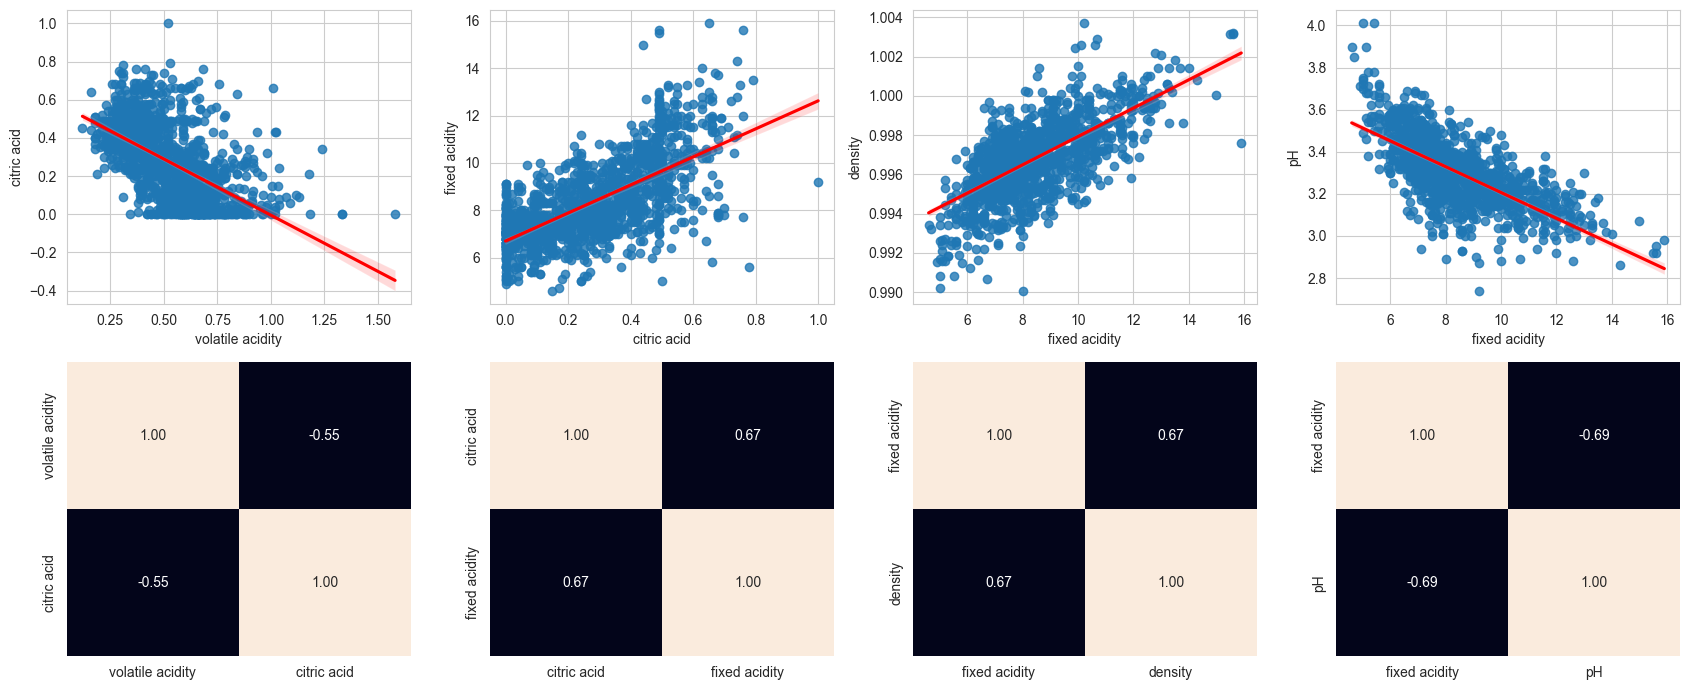

In [21]:
corr_volatile_citric = df[["volatile acidity", "citric acid"]].corr()
corr_citric_fixed = df[["citric acid", "fixed acidity"]].corr()
corr_fixed_density = df[["fixed acidity", "density"]].corr()
corr_fixed_ph = df[["fixed acidity", "pH"]].corr()
fig, axis = plt.subplots(2, 4, figsize=(17, 7))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="volatile acidity", y="citric acid", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_volatile_citric, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="citric acid", y="fixed acidity", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_citric_fixed, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="fixed acidity", y="density", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_fixed_density, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,3], data=df, x="fixed acidity", y="pH", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,3], data=corr_fixed_ph, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

#### Hay una fuerte correlación y linealidad entre estas variables que a su vez se relacionan con otras y así por todo el conjunto de datos. Podemos decir que cada componente influye en la calidad del producto

## Ingeniería de características

### Análisis de outliers

#### Análisis descriptivo

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


#### Visualización

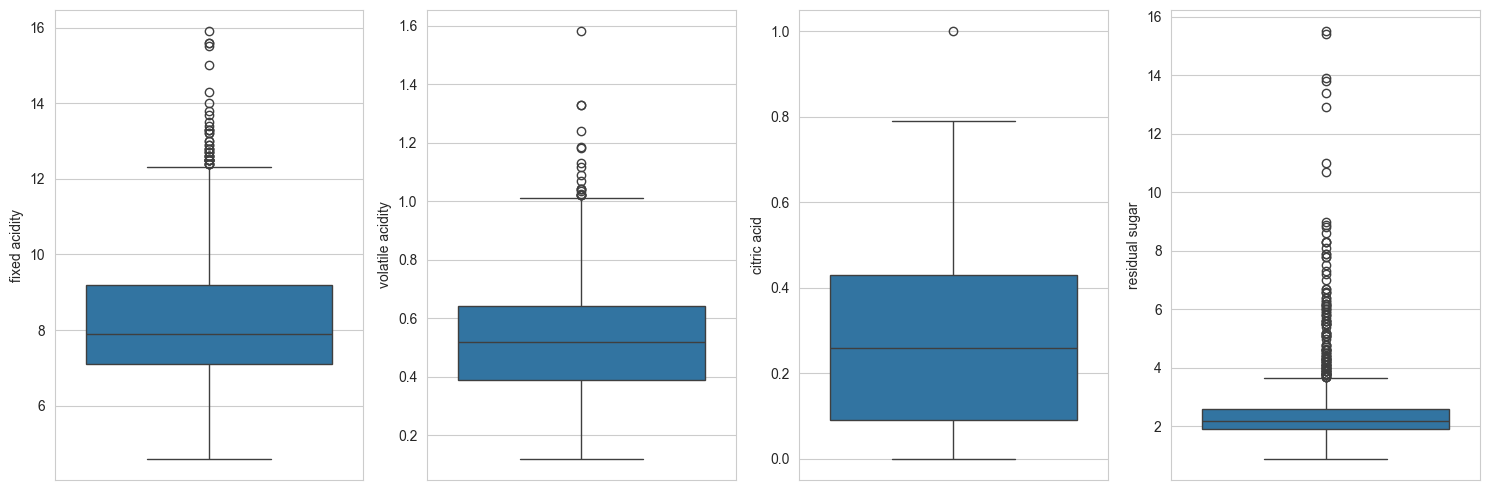

In [23]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="fixed acidity")
sns.boxplot(ax=axis[1], data=df, y="volatile acidity")
sns.boxplot(ax=axis[2], data=df, y="citric acid")
sns.boxplot(ax=axis[3], data=df, y="residual sugar")
plt.tight_layout()
plt.show()

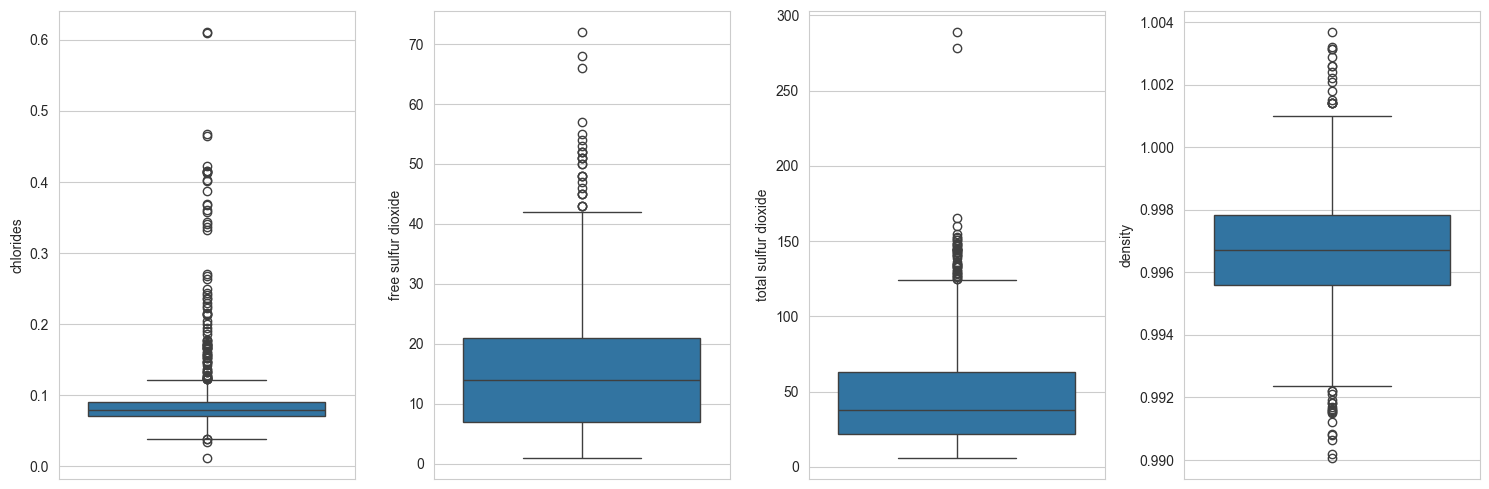

In [24]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="chlorides")
sns.boxplot(ax=axis[1], data=df, y="free sulfur dioxide")
sns.boxplot(ax=axis[2], data=df, y="total sulfur dioxide")
sns.boxplot(ax=axis[3], data=df, y="density")
plt.tight_layout()
plt.show()

In [25]:
df.sort_values(by='quality', ascending=False)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1549,7.4,0.360,0.30,1.80,0.074,17.0,24.0,0.99419,3.24,0.70,11.4,8
1403,7.2,0.330,0.33,1.70,0.061,3.0,13.0,0.99600,3.23,1.10,10.0,8
481,9.4,0.300,0.56,2.80,0.080,6.0,17.0,0.99640,3.15,0.92,11.7,8
495,10.7,0.350,0.53,2.60,0.070,5.0,16.0,0.99720,3.15,0.65,11.0,8
1120,7.9,0.540,0.34,2.50,0.076,8.0,17.0,0.99235,3.20,0.72,13.1,8
...,...,...,...,...,...,...,...,...,...,...,...,...
459,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
517,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
690,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
899,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3


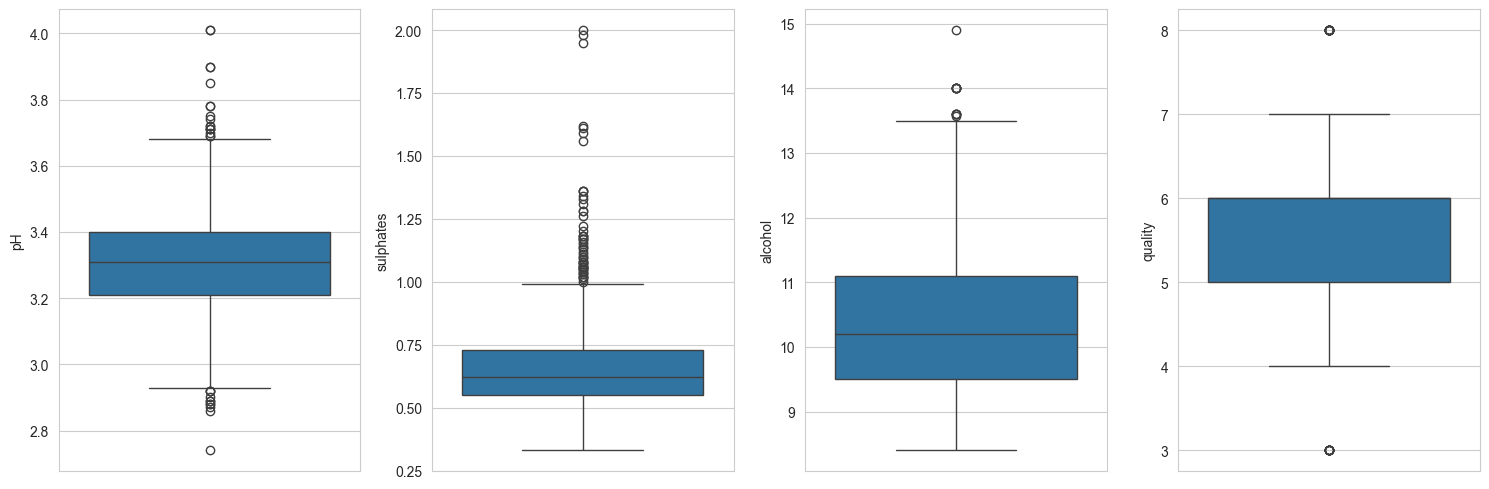

In [26]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="pH")
sns.boxplot(ax=axis[1], data=df, y="sulphates")
sns.boxplot(ax=axis[2], data=df, y="alcohol")
sns.boxplot(ax=axis[3], data=df, y="quality")
plt.tight_layout()
plt.show()

### Observaciones:

>- #### Buscando en internet podemos obtener los valores máximos normales para estas variables:

| **Variable**             | **Descripción breve**                          | **Valor máximo lógico aproximado** |
|--------------------------|------------------------------------------------|------------------------------------|
| Fixed acidity            | Principalmente ácido tartárico                 | ~16 g/L                            |
| Volatile acidity         | Ácido acético (vinagre)                        | ~1.5 g/L                           |
| Citric acid              | Ácido natural, mejora sabor                    | ~1.0 g/L                           |
| Residual sugar           | Azúcares que no se fermentaron                 | ~65 g/L (en vinos dulces)          |
| Chlorides                | Sales (principalmente cloruro de sodio)        | ~0.2 g/L                           |
| Free sulfur dioxide      | SO₂ libre, protege contra microbios            | ~72 mg/L                           |
| Total sulfur dioxide     | Incluye libre + combinado                      | ~290 mg/L (límite legal EU)       |
| Density                  | Relación masa/volumen (g/cm³)                  | ~1.04                              |
| pH                       | Acidez total (bajo = más ácido)                | ~4.0                               |
| Sulphates                | Conservante y antioxidante (SO₄²⁻)             | ~2.0 g/L                           |
| Alcohol                  | Contenido alcohólico                           | ~15–16 % vol.                      |


#### Observamos que los datos del conjunto están dentro de estos valores menos el de clhorides, aunque lo mantendremos porque no parece que sea un valor demasiado exagerado por lo tanto decido mantenerlos


### Análisis de valores faltantes

In [27]:
df.isnull().sum().sort_values(ascending=False) / len(df)

fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

#### En este caso no existen valores nulos



### Inferencia de carácteristicas

#### El ejercicio nos pide que trabajemos con valores para la calidad de 0,1 y 2 así que convertimos los valores de 'quality'

In [28]:
df["label"] = pd.cut(df["quality"], bins=[2, 4, 6, 8], labels=[0, 1, 2], include_lowest=True)
df["label"] = df["label"].astype(int)


In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
 12  label                 1359 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 148.6 KB


## Split de datos (elegimos la variable quality como target)


In [30]:
X = df.drop(['quality', 'label'], axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
995,7.7,0.600,0.06,2.0,0.079,19.0,41.0,0.99697,3.39,0.62,10.1
59,7.3,0.390,0.31,2.4,0.074,9.0,46.0,0.99620,3.41,0.54,9.4
375,11.5,0.540,0.71,4.4,0.124,6.0,15.0,0.99840,3.01,0.83,11.8
1371,7.5,0.580,0.56,3.1,0.153,5.0,14.0,0.99476,3.21,1.03,11.6
1469,7.3,0.980,0.05,2.1,0.061,20.0,49.0,0.99705,3.31,0.55,9.7
...,...,...,...,...,...,...,...,...,...,...,...
164,7.3,0.590,0.26,7.2,0.070,35.0,121.0,0.99810,3.37,0.49,9.4
393,8.4,0.665,0.61,2.0,0.112,13.0,95.0,0.99700,3.16,0.54,9.1
216,8.7,0.625,0.16,2.0,0.101,13.0,49.0,0.99620,3.14,0.57,11.0
1056,8.9,0.480,0.53,4.0,0.101,3.0,10.0,0.99586,3.21,0.59,12.1


## Scaling & Encoding

### Scaling

#### Usamos el método RobustScaler porque es mejor para un modelo de KN-neighbors con valores atípicos

#### Scaling X_train

In [31]:
robust_scaler = RobustScaler() 
num_variables = X_train.columns.tolist()
robust_train_features = robust_scaler.fit_transform(X_train[num_variables])
X_train_scaled = pd.DataFrame(robust_train_features,
                              index=X_train.index,
                              columns=num_variables)
X_train_scaled

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
995,-0.095238,0.36,-0.606061,-0.285714,0.000000,0.357143,0.047619,0.075221,0.421053,0.000000,-0.0625
59,-0.285714,-0.48,0.151515,0.285714,-0.238095,-0.357143,0.166667,-0.265487,0.526316,-0.444444,-0.5000
375,1.714286,0.12,1.363636,3.142857,2.142857,-0.571429,-0.571429,0.707965,-1.578947,1.166667,1.0000
1371,-0.190476,0.28,0.909091,1.285714,3.523810,-0.642857,-0.595238,-0.902655,-0.526316,2.277778,0.8750
1469,-0.285714,1.88,-0.636364,-0.142857,-0.857143,0.428571,0.238095,0.110619,0.000000,-0.388889,-0.3125
...,...,...,...,...,...,...,...,...,...,...,...
164,-0.285714,0.32,0.000000,7.142857,-0.428571,1.500000,1.952381,0.575221,0.315789,-0.722222,-0.5000
393,0.238095,0.62,1.060606,-0.285714,1.571429,-0.071429,1.333333,0.088496,-0.789474,-0.444444,-0.6875
216,0.380952,0.46,-0.303030,-0.285714,1.047619,-0.071429,0.238095,-0.265487,-0.894737,-0.277778,0.5000
1056,0.476190,-0.12,0.818182,2.571429,1.047619,-0.785714,-0.690476,-0.415929,-0.526316,-0.166667,1.1875


#### Scaling X_test

In [32]:

X_test_scaled = pd.DataFrame(robust_scaler.transform(X_test[num_variables]),
                               index=X_test.index,
                               columns=num_variables)
X_test_scaled

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
887,1.333333,0.04,0.363636,0.571429,-0.619048,1.071429,0.404762,-0.455752,-0.842105,0.944444,1.1875
717,-0.142857,-0.20,-0.454545,0.571429,0.000000,-0.142857,0.238095,0.000000,-0.526316,-0.277778,-0.1250
221,-0.238095,0.08,0.000000,-0.285714,1.047619,0.142857,0.785714,-0.486726,-0.842105,-0.277778,-0.5000
1218,0.142857,-0.44,0.151515,-0.428571,0.142857,-0.428571,-0.357143,-0.353982,-0.368421,0.388889,0.2500
1487,-0.904762,0.52,-0.636364,-0.428571,-0.619048,-0.357143,-0.523810,-0.814159,1.105263,0.888889,0.2500
...,...,...,...,...,...,...,...,...,...,...,...
1003,-0.523810,-0.60,0.181818,-0.571429,-0.571429,-0.714286,-0.738095,-1.769912,0.263158,-0.388889,1.6250
739,0.523810,0.72,-0.787879,0.285714,0.428571,0.357143,-0.023810,0.973451,0.210526,-0.111111,-0.5625
645,-0.047619,0.52,-0.484848,5.428571,1.714286,-0.642857,-0.666667,0.707965,0.315789,0.388889,-0.0625
1300,-1.285714,0.54,-0.787879,-0.071429,0.047619,0.071429,-0.261905,-1.044248,2.473684,-0.055556,1.4375


In [33]:
X_train_scaled.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/xtrain-knn.csv", index=False)
X_test_scaled.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/xtest-knn.csv", index=False)
y_train.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/ytrain-knn.csv", index=False)
y_test.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/ytest-knn.csv", index=False)
